In [2]:
import pandas as pd
import numpy as np
from prophet import Prophet
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)  # quiets Prophet's noisy logs

df = pd.read_csv('data/raw/train.csv')
df['date'] = pd.to_datetime(df['date'])

selected = [(1, 1), (5, 10), (10, 25)]

In [3]:
results = {}

for store, item in selected:
    subset = df[(df['store']==store) & (df['item']==item)][['date','sales']].sort_values('date')
    subset.columns = ['ds', 'y']

    split_date = subset['ds'].max() - pd.Timedelta(days=90)
    train = subset[subset['ds'] <= split_date]
    test = subset[subset['ds'] > split_date]

    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    model.fit(train)

    future = model.make_future_dataframe(periods=len(test))
    forecast = model.predict(future)

    forecast_test = forecast[forecast['ds'] > split_date][['ds','yhat']]
    merged = test.merge(forecast_test, on='ds')

    results[(store, item)] = merged
    print(f"Store {store}, Item {item}: fitted, {len(test)} test days")

22:15:06 - cmdstanpy - INFO - Chain [1] start processing
22:15:07 - cmdstanpy - INFO - Chain [1] done processing
22:15:07 - cmdstanpy - INFO - Chain [1] start processing
22:15:07 - cmdstanpy - INFO - Chain [1] done processing


Store 1, Item 1: fitted, 90 test days


22:15:08 - cmdstanpy - INFO - Chain [1] start processing


Store 5, Item 10: fitted, 90 test days


22:15:08 - cmdstanpy - INFO - Chain [1] done processing


Store 10, Item 25: fitted, 90 test days


In [4]:
metrics = []
for (store, item), merged in results.items():
    mape = np.mean(np.abs(merged['y'] - merged['yhat']) / merged['y']) * 100
    bias = np.mean(merged['yhat'] - merged['y'])
    metrics.append({'store': store, 'item': item, 'mape': mape, 'bias': bias})

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

   store  item       mape      bias
0      1     1  23.263345  0.905805
1      5    10  12.135743  0.189798
2     10    25  11.336995  1.580431


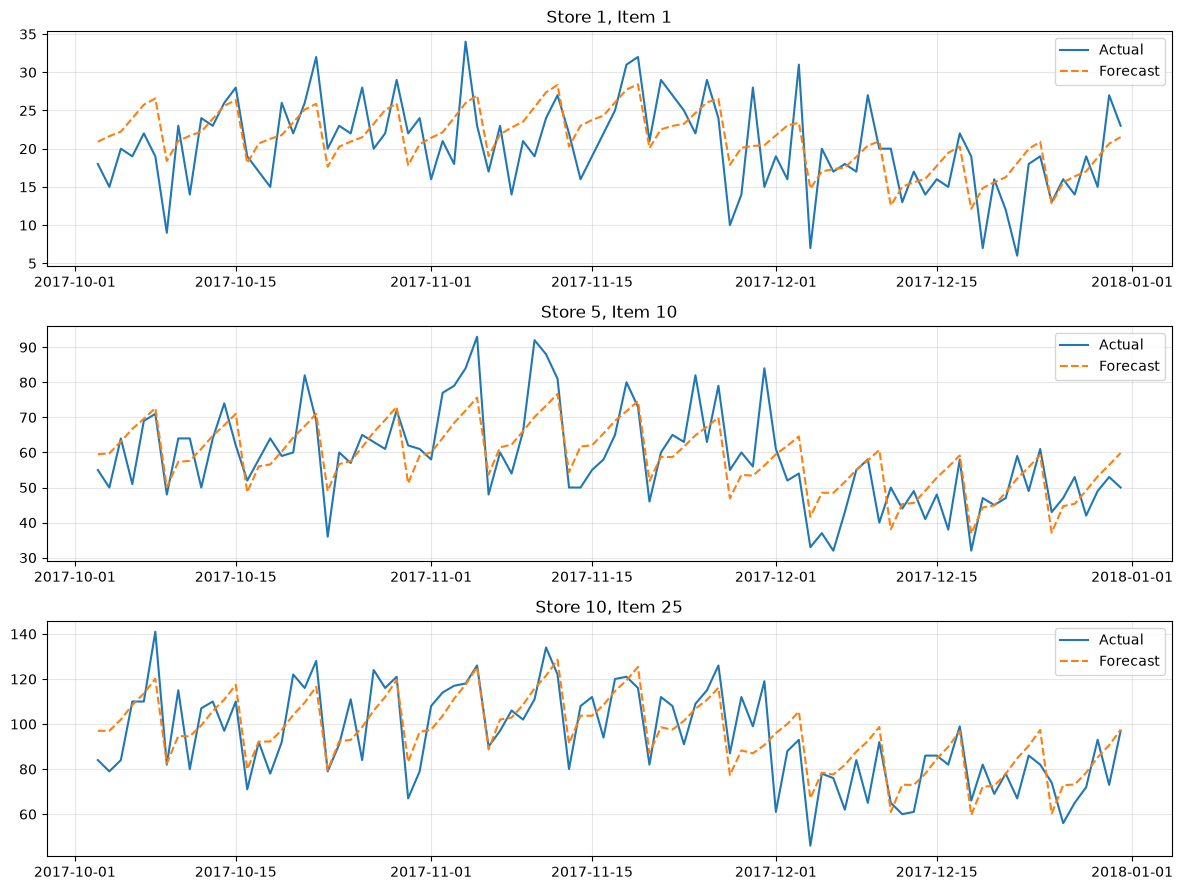

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
for idx, ((store, item), merged) in enumerate(results.items()):
    axes[idx].plot(merged['ds'], merged['y'], label='Actual', linewidth=1.5)
    axes[idx].plot(merged['ds'], merged['yhat'], label='Forecast', linewidth=1.5, linestyle='--')
    axes[idx].set_title(f'Store {store}, Item {item}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
import os
os.makedirs('data/processed', exist_ok=True)

all_results = pd.concat([
    merged.assign(store=store, item=item)
    for (store, item), merged in results.items()
])
all_results.to_csv('data/processed/forecast_results.csv', index=False)
metrics_df.to_csv('data/processed/forecast_metrics.csv', index=False)
print("Saved forecast results and metrics")

Saved forecast results and metrics
